In [9]:
import subprocess
import os
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from IPython.display import clear_output
from time import sleep
import seaborn as sns
import pickle

In [10]:
vlist_directory = '../../test_dwnld/'

url = 'https://stsw1.isee.nagoya-u.ac.jp/vlist/'

file_name = [str((x - 1900)%100) if len(str((x - 1900)%100))>1 else '0'+str((x - 1900)%100) for x in range(1983, 2025) ]

file_name = ['VLIST' + x for x in file_name]

print(file_name)
print(f"\nData obtained from {url}.")

['VLIST83', 'VLIST84', 'VLIST85', 'VLIST86', 'VLIST87', 'VLIST88', 'VLIST89', 'VLIST90', 'VLIST91', 'VLIST92', 'VLIST93', 'VLIST94', 'VLIST95', 'VLIST96', 'VLIST97', 'VLIST98', 'VLIST99', 'VLIST00', 'VLIST01', 'VLIST02', 'VLIST03', 'VLIST04', 'VLIST05', 'VLIST06', 'VLIST07', 'VLIST08', 'VLIST09', 'VLIST10', 'VLIST11', 'VLIST12', 'VLIST13', 'VLIST14', 'VLIST15', 'VLIST16', 'VLIST17', 'VLIST18', 'VLIST19', 'VLIST20', 'VLIST21', 'VLIST22', 'VLIST23', 'VLIST24']

Data obtained from https://stsw1.isee.nagoya-u.ac.jp/vlist/.


In [11]:
# There were some extra coloumns, ignoring them at the momemnt.
columns_extra =['RA(B1950)_0', 'RA(B1950)_1', 'RA(B1950)_2', 'DC(B1950)_0',
                'DC(B1950)_1','DC(B1950)_2', 'RA(J2000)_0', 'RA(J2000)_1', 'RA(J2000)_2', 'DC(J2000)_0', 
                'DC(J2000)_1', 'DC(J2000)_2']
column_names = ['SOURCE', 'YRMNDY', 'UT', 'DIST', 'HLA',  'HLO', 'GLA', 'GLO', 'CARR', 
                'V', 'ER', 'SC-INDX', 'file']
column_names = [x.lower() for x in column_names]
print(column_names)

['source', 'yrmndy', 'ut', 'dist', 'hla', 'hlo', 'gla', 'glo', 'carr', 'v', 'er', 'sc-indx', 'file']


In [12]:
# Here we concatenate files having read them one after the other as they ocuur in file_names.
# Note: everytime the index needs to redifined to start from where the previous file left off.
# An extra coloumn 'file' is added to keep track.


df_test_1 = pd.DataFrame(columns=column_names)
for x in file_name:
    indx_strt = df_test_1.shape[0]
    df_test_0 = pd.read_csv(vlist_directory + x, sep='\s+', skipinitialspace=True, skiprows=8, header=None, 
                        names=column_names[0:-1], usecols=[y for y in range(len(column_names[0:-1]))])
    df_test_0.index = df_test_0.index + indx_strt
    df_test_0['file'] = [x for i in range(df_test_0.shape[0])]
    df_test_1 = pd.concat([df_test_1, df_test_0])  

In [13]:
"""
In the rows where the error 'er' entry is -999 there was no space between the the entry for 'er' and 'v' (wind speed).
Therefore the combined reading of 'v' and 'er' was entered as a string in 'v'. 
Also some entries of 'v' where string instead of int.
Below we have a fucntion which can be applied row-wise to the data frame. 
"""
def v_err(row):
    if type(row.v) == str:
        if row.v[-4:] == '-999':
            row.v = int(row.v[0:-4])
            row['sc-indx'] = row.er
            row.er = -999
        else:
            row.v = int(row.v)
    return row
  

In [14]:
# Implementing v_err 
df_test_1 = df_test_1.apply(v_err, axis=1)

In [15]:
print(f"{df_test_1.shape}")

(132077, 13)


In [16]:
# Implementing one-hot encoding for error 'er' values of -999 in new coloumn 'er_1'

df_test_1['er_1'] = df_test_1.er.map(lambda x: 1 if x==-999 else 0)
df_test_1

,source,yrmndy,ut,dist,hla,hlo,gla,glo,carr,v,er,sc-indx,file,er_1
0,3C48,830325,4.30,0.60,28,-46,22,179,1733,385,14.0,1290.0,VLIST83,0
1,3C48,830326,4.23,0.59,29,-47,23,165,1733,363,54.0,2310.0,VLIST83,0
2,3C48,830327,4.17,0.58,30,-47,24,151,1733,408,58.0,1280.0,VLIST83,0
3,3C48,830328,4.10,0.57,31,-47,25,138,1733,531,16.0,2370.0,VLIST83,0
4,3C48,830329,4.03,0.56,32,-48,26,124,1733,472,0.0,1550.0,VLIST83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132072,1428-03,241215,23.70,0.74,9,41,4,328,2292,653,-999.0,0.0,VLIST24,1
132073,1436-16,241215,23.85,0.65,-2,49,-8,335,2292,328,-999.0,0.0,VLIST24,1
132074,1441-102,241215,23.93,0.66,6,47,0,334,2292,580,-999.0,0.0,VLIST24,1
132075,1644-106,241216,1.98,0.29,41,67,34,354,2292,402,-999.0,0.0,VLIST24,1


In [17]:
# The 'yrmndy' is read as an integer, so converting it into a string and adding required zeros
# for the first few years in the 2000s
def yr_mod(col):
    x = str(col)
    if len(str(x))<6:
        x = ''.join([ '0' for j in range(6 - len(x)) ]) + str(x) 
    else:
         x 
    return x

pd.to_datetime('000504', format='%y%m%d')

Timestamp('2000-05-04 00:00:00')

In [18]:
# Implementing datetime stamp on 'yrmndy'
df_test_1['yrmndy'] = pd.to_datetime(df_test_1.yrmndy.map(yr_mod), format='%y%m%d')

In [19]:
# Copying to make changes in the copy to avoid running the whole file fromthe top
df_test_2 = df_test_1.copy()

In [20]:
# Implementing conversion to datetime by adding yrmndy to it
# df_test_2['ut'] = df_test_2.ut.round()
df_test_2['ut'] = df_test_2.yrmndy + pd.to_timedelta(df_test_2.ut, unit='h')
df_test_2

,source,yrmndy,ut,dist,hla,hlo,gla,glo,carr,v,er,sc-indx,file,er_1
0,3C48,1983-03-25,1983-03-25 04:18:00,0.60,28,-46,22,179,1733,385,14.0,1290.0,VLIST83,0
1,3C48,1983-03-26,1983-03-26 04:13:48,0.59,29,-47,23,165,1733,363,54.0,2310.0,VLIST83,0
2,3C48,1983-03-27,1983-03-27 04:10:12,0.58,30,-47,24,151,1733,408,58.0,1280.0,VLIST83,0
3,3C48,1983-03-28,1983-03-28 04:06:00,0.57,31,-47,25,138,1733,531,16.0,2370.0,VLIST83,0
4,3C48,1983-03-29,1983-03-29 04:01:48,0.56,32,-48,26,124,1733,472,0.0,1550.0,VLIST83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132072,1428-03,2024-12-15,2024-12-15 23:42:00,0.74,9,41,4,328,2292,653,-999.0,0.0,VLIST24,1
132073,1436-16,2024-12-15,2024-12-15 23:51:00,0.65,-2,49,-8,335,2292,328,-999.0,0.0,VLIST24,1
132074,1441-102,2024-12-15,2024-12-15 23:55:48,0.66,6,47,0,334,2292,580,-999.0,0.0,VLIST24,1
132075,1644-106,2024-12-16,2024-12-16 01:58:48,0.29,41,67,34,354,2292,402,-999.0,0.0,VLIST24,1


In [21]:
sun_spots = pd.read_csv('../../SN_d_tot_V2.0.csv', sep=";", names=['year', 'month', 'day', 'date_frac', 'day_total', 'day_std', 'num' ,'d_p'])

# Implementing a 'yrmndy' column from 'year', 'month' and 'day', and dropping the latter columns 
sun_spots['yrmndy'] = pd.to_datetime(sun_spots[["year", "month", "day"]])
sun_spots.drop(columns=['year', 'month', 'day', 'date_frac'], inplace=True)
sun_spots.head()

,day_total,day_std,num,d_p,yrmndy
0,-1,-1.0,0,1,1818-01-01
1,-1,-1.0,0,1,1818-01-02
2,-1,-1.0,0,1,1818-01-03
3,-1,-1.0,0,1,1818-01-04
4,-1,-1.0,0,1,1818-01-05


In [22]:
# Editing -1 in 'day_total' and 'day_std' to reflect np.nan
sun_spots['day_total'] = sun_spots.day_total.apply(lambda x: np.nan if x == -1 else x)
sun_spots['day_std'] = sun_spots.day_std.apply(lambda x: np.nan if x == -1 else x)

In [23]:
# Defining OMNI start date
# This is the date from which Datta has currated the OMNI data w.r.t. smoothness
# The official OMNI data starts from 1963
omni_start_date_str = "1996-08-01 12:00:00"
omni_start_date_prv_mnth_str = "1996-07-01 12:00:00"

In [24]:
"-".join([
    x 
    if i != 1 
    else (str(int(x) + 1) if len(str(int(x) + 1)) == 2 else "0"+str(int(x) + 1))  
    for i, x in enumerate(str(omni_df.iloc[0,0]).split("-"))
])

NameError: name 'omni_df' is not defined

In [25]:
# Define sun_spots_recent as the from the start the OMNI data
sun_spots_recent = sun_spots.loc[sun_spots.yrmndy >= pd.to_datetime(omni_start_date_prv_mnth_str)].copy()

In [26]:
# Defining conditions on the IPS data to be currated
cond = (df_test_2.er_1==0) & (df_test_2.er < 50) & (df_test_2.dist < 0.8) & (df_test_2.dist > 0.25)

df_test_3 = df_test_2.loc[cond].copy()

# delta_t is the number of days between the start of the IPS data and 2050-01-01
delta_t = (lambda x: x.days + x.seconds/(24*60*60))(pd.to_datetime('2050-01-01') - df_test_3.ut.min()) # no.of days from first obs to 2050-01-01
print(delta_t)

# Defining 'time' as 1e3*(1 - day_diff/delta_t) where
# day_diff = no.of days between 2050-01-01 and time of IPS obs in 'ut' column.
# This time would be used for making the final data
df_test_3['time'] =  (1000 - (pd.to_datetime('2050-01-01') - df_test_3.ut).map(lambda x: 1000*(x.days + x.seconds/(24*60*60)))/delta_t).round(8)
# df_test_2['time'] =  (pd.to_datetime('2050-01-01') - df_test_2.ut).map(lambda x: x.seconds/(24*60*60)).round(8)
df_test_3

24388.820833333335


,source,yrmndy,ut,dist,hla,hlo,gla,glo,carr,v,er,sc-indx,file,er_1,time
0,3C48,1983-03-25,1983-03-25 04:18:00,0.60,28,-46,22,179,1733,385,14.0,1290.0,VLIST83,0,0.000000
3,3C48,1983-03-28,1983-03-28 04:06:00,0.57,31,-47,25,138,1733,531,16.0,2370.0,VLIST83,0,0.122665
4,3C48,1983-03-29,1983-03-29 04:01:48,0.56,32,-48,26,124,1733,472,0.0,1550.0,VLIST83,0,0.163548
5,3C48,1983-03-30,1983-03-30 03:58:12,0.55,33,-48,27,111,1733,404,0.0,2880.0,VLIST83,0,0.204448
6,3C48,1983-03-31,1983-03-31 03:54:00,0.54,34,-49,28,97,1733,360,0.0,0.0,VLIST83,0,0.245331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131865,1535+139,2024-11-02,2024-11-02 03:41:24,0.54,55,-19,61,132,2290,659,4.0,29.1,VLIST24,0,623.153316
131866,1548+05,2024-11-02,2024-11-02 03:54:36,0.47,51,-41,58,106,2290,351,1.0,19.0,VLIST24,0,623.153692
131935,1638-025,2024-11-16,2024-11-16 03:49:48,0.41,47,-53,54,269,2291,638,22.0,13.5,VLIST24,0,623.727589
131944,3C298,2024-11-18,2024-11-18 01:20:24,0.52,32,52,28,350,2291,568,48.0,13.7,VLIST24,0,623.805340


In [27]:
# Merge sun_spots_recent  to the left on 'yrmndy' column
df_test_3 = pd.merge(left=df_test_3, right=sun_spots_recent[['yrmndy', 'day_total']], on='yrmndy', how='left')

In [28]:
# Note some time intervals the the format used in 'time' column
# 6 day interval in terms of units of the time col. i.e. 6x1000/delta_t
# where delta_t is the no.of days between 2050-01-01 and first obs.
delta_6 = 6*1e3/delta_t
delta_8 = 8*1e3/delta_t
print('6 days =',delta_6 , '8 days =',delta_8 , '.   1day =',(1)*1e3/delta_t, '.   1hr =',(1/24)*1e3/delta_t, '.   5min =',(1/(24*12))*1e3/delta_t)
round(delta_6, 5)
delta_1h = (1/24)*1e3/delta_t

6 days = 0.24601435391249096 8 days = 0.32801913854998793 .   1day = 0.04100239231874849 .   1hr = 0.0017084330132811872 .   5min = 0.00014236941777343227


In [65]:
(1/24)/delta_t

1.7084330132811872e-06

In [29]:
# OMNI start date in 'time' column format
omni_start_date = round((lambda x: 1000 - 1000*(x.days + x.seconds/(24*60*60))/delta_t)(pd.to_datetime('2050-01-01') - pd.to_datetime("1996-08-01 12:00:00")), 8)
print(f"OMNI start date is calibrated to {omni_start_date}")

OMNI start date is calibrated to 200.02282467


In [30]:
# Selecting IPS data from 8-days prior to start of omni_start_date
df_4 = df_test_3.loc[df_test_3.time >= omni_start_date - delta_8] # IPS data set from 8days before start of omni data set
drop_cols = ['source', 'yrmndy', 'ut', 'file', 'er_1'] ## columns to be dropped during training
df_5 = df_4.drop(columns=drop_cols).copy()
df_5.reset_index(inplace=True)

In [31]:
# Save df_5 to disk
df_5.to_csv("IPS_Sunspots_curated.csv", index=False)

In [32]:
def find_ranked_er(time, time_delta):
    """
    Parameters:
    --------------------------------------------------
    time: time in df_5.time format
    time_delta: time interval in df_5.time format


    Returns:
    -------------------------------------------------
    np.array of ranked list of df_5 indices according to least error i.e. df_5.er
    """
    df = df_5.loc[(df_5.time <= time) & (df_5.time > time - time_delta)]
    if len(df) > 0:
        return df.er.sort_values().index
    else:
        return np.array([])

In [33]:
def fill_bracket(time_0, time_1, intervals):
    """
    Params:
    -----------------------------------------------
    time_0: time in time formart of df_5
    time_1: < time_0
    intervals: total # equally spaced time intervals b/w time_0 and time_1

    Returns:
    -------------------------------------------------
    'intervals' many obs- with one obs of least error in each interval, as a pd.DataFrame().values.
    If no value is found in an interval, then its filled with the remainder set once all the intervals have been filled with the best within them 
    """
    time_delta = (time_0 - time_1)/intervals # size of each interval
    # print(time_delta)
    df = df_5.loc[(df_5.time <= time_0) & (df_5.time > time_1)].copy()

    
    if len(df) <= intervals:
        bracket = df
        # print('less')
    else:
        # print('more')
        # First fill in the intervals with the best obs from the same interval
        rest_obs_id = np.array([])
        empty_list = [] # list for intervals with no obs
        bracket = []   # to store obs rows
        for i in range(intervals):
            obs_id = find_ranked_er(time_0 - i*time_delta, time_delta)     ## get list of indices with obs in the interval ranked acc. to error i.e. df_5.er
            # print(i)
            if len(obs_id) != 0:
                bracket.append(df.loc[df.index==obs_id[0]].values.reshape((1,-1)).tolist())
                if len(obs_id) > 1:
                    obs_id = np.delete(obs_id, 0)
                    rest_obs_id = np.concatenate((rest_obs_id, obs_id))   # storing the ranked obs indices for filling unfilled intervals
                # break
            else:
                empty_list.append(i) # keeping track of empty intervals
    
        bracket = np.array(bracket)
        bracket = bracket.reshape((-1,len(df_5.columns))) 
        # print(bracket.shape)
        
        # Fill the rest of the intervals if any with the remainder of obs from other intervals
        rest_obs_id = rest_obs_id.astype(int)
        if len(rest_obs_id) > 0:
            for i, obs_j in zip(empty_list, rest_obs_id):
                # print(obs_j in list(df.index))
                bracket = np.concatenate((bracket, df.loc[df.index==obs_j].values.reshape((1,-1))))

    # Arranging the dataset according to time
    bracket = pd.DataFrame(bracket, columns=df.columns)
    bracket.drop(columns=['index'], inplace=True)
    bracket.sort_values('time', ascending=False, inplace=True)
    bracket.reset_index(inplace=True)
    bracket.drop(columns='index', inplace=True)
    del df
    return bracket

In [34]:
omni = pd.read_csv('../../omni_avg_normalised_smoothed_extened.csv')
# omni.head()
omni.rename(columns={'Unnamed: 0':'yrmndy_hr'}, inplace=True)
omni.columns

Index(['yrmndy_hr', 'swSpeed', 'swBx', 'swBy', 'swBz', 'swRho',
       'swSpeed_Smth_0', 'swBx_Smth_0', 'swBy_Smth_0', 'swBz_Smth_0',
       'swRho_Smth_0'],
      dtype='object')

In [35]:
# Selecting omni columns and inserting a 'time' column similar to one in the curated IPS data in df_5

omni_df = omni[['yrmndy_hr', 'swSpeed_Smth_0']].copy()

omni_df['yrmndy_hr'] = pd.to_datetime(omni_df.yrmndy_hr)

omni_df['time'] = (1000 - (pd.to_datetime('2050-01-01') - omni_df.yrmndy_hr).map(lambda x: 1000*(x.days + x.seconds/(24*60*60)))/delta_t).round(8)

omni_df.drop(columns=['yrmndy_hr'], inplace=True)

In [36]:
# Saving the curated OMNI data to disk
omni_df.to_csv("OMNI_curated.csv", index=False)

In [37]:
def make_training_data(ips_data, omni_data, min_input_len=20):
    """
    Construct training data as follows:
    Begining at every hour i of the omni_data construct
    the target y: 16 omni_data obs into the future begining at hour i i.e. omin_data 4 days into the future
    the input  x: best ips_data from 8-days into the past begining from the hour i as a pd.DataFrame().values
    
    
    The length of the omni_data controls the length of the output.
    If the input x generated doesn't have length of min_len_input then the data corresponding to the hour i is not considered.
    
    Params:
    -----------------------------------------------------------------------------------------------------------------------------------------------------------
    omni_data: omni data as pd.DataFrame with time as in time in df_5 and smoothed hourly solar wind speed.
    ips_data: ips pd.DataFrame() with relevant columns and time as above along with sun spot numbers for the relevant days.
    min_input_len: min number of ips_data in the past 8-days- if less, then the data point is skipped.

    Returns:
    -----------------------------------------------------------------------------------------------------------------------------------------------------------
    A list s.t. each row is a list [i, x, y] where 
    i: is the index starting from 0
    y: is the above target and 
    x: is the above (2dim with x.shape:(32, #selected columns from ips_data)) input
    
    A missing list containing rows [i, missed] where
    i: the index where no.of x data generated is not of length of 32
    missed: length of x data
    """
    
    out_data = [] 
    j = 0  # index 
    k = 0  # no.of samples skipped
    missing = []
    for i in range(len(omni_data) - 16):
        time = omni_data.iloc[i].time
        x_brckt = fill_bracket(time, time - delta_8, 32) # x_brckt has max len 32, it can be smaller
        x_brckt_len = len(x_brckt)
        # Do not make sample if x_brckt has len < 20
        if x_brckt_len < min_input_len:
            k = k + 1
            continue
        
        # adding an extra column in x for keeping track of the time of the input
        # this column has time as its entry for the first len(x_brckt) entries  
        # and then np.zeros for the remainding entries upto 32 if len(x_brckt) < 32
        # print(len(x_brckt))


        if x_brckt_len < 32:
            x_brckt_0 = pd.DataFrame(np.zeros(11*(32 - x_brckt_len)).reshape((32 - x_brckt_len), -1), columns=x_brckt.columns)
            x_brckt = pd.concat([x_brckt, x_brckt_0])
        # if len(x_brckt) == 32:
        #     time_0 = time*np.ones(32)
        # else:
        #     time_0 = np.concatenate((time*np.ones(len(x_brckt)), np.zeros(32 - len(x_brckt)) ))
        time_0 = time*np.ones(32)
        # x_brckt['time_trgt'] = pd.Series(time_0)
        x_brckt['time_trgt'] = time_0
        # Adding input column to indicate missing rows as 0
        # x_brckt['input'] = pd.Series(np.concatenate([np.ones(x_brckt_len), np.zeros(32 - x_brckt_len)]), dtype=float)
        x_brckt['input'] = np.concatenate([np.ones(x_brckt_len), np.zeros(32 - x_brckt_len)])
        
        
        # Test x_brckt['input'].sum()
        # print(x_brckt['input'].values.sum(), x_brckt_len, pd.Series(np.concatenate([np.ones(x_brckt_len), np.zeros(32 - x_brckt_len)]), dtype=float).values.sum())
        if x_brckt_len != x_brckt['input'].sum():
            print(x_brckt['input'].sum(), x_brckt_len, x_brckt.input.values)
            
            
        # Uncomment line below to return a list with X and y as pd.DataFrames
        # out_data.append([j, x_brckt, omni_data.iloc[i: i + 16] ]) 
            
        out_data.append([j] + list(x_brckt.values.reshape(-1)) + list(omni_data.iloc[i: i+16].values.reshape(-1)))
        
        # Keep track of x_brckt when len < 32
        if x_brckt_len < 32:
            missing.append([j, x_brckt_len])
        
        j = j + 1
            
    print(f"{k} Data points skipped due to lack of atleast {min_input_len} IPS data points in the past 8-days.")
    
    missing_df = pd.DataFrame(missing, columns=['id', 'missed'])
    if len(missing) > 0:
        print(missing_df.describe().to_string())
    print(f"{j} Data points made.")
    # return out_data, missing

    clmns_ips = list(ips_data.columns)
    clmns_ips.pop(0)
    clmns_ips.append('time_trgt')
    clmns_ips.append('input')
    print(clmns_ips, len(clmns_ips))
    clmns_input = []
    for i in range(32):
        for clmn in clmns_ips:
            clmns_input.append(f"X_{clmn}_{i}")
    # print(clmns_input)
    clmns_omni = list(omni_data.columns)
    clmns_target = []
    for i in range(16):
        for clmn in clmns_omni:
            clmns_target.append(f"y_{clmn}_{i}")
    clmns_data = ['idx'] + clmns_input + clmns_target
    
    out_df = pd.DataFrame(out_data, columns=clmns_data)
    
    return out_df, missing_df

In [38]:
# Generating column names in list clmns_data for the final data from curated IPS data:df_5 and curated OMNI data: omni_df

clmns_ips = list(df_5.columns)
clmns_ips.pop(0)
clmns_ips.append('time_trgt')
clmns_ips.append('input')
print(clmns_ips, len(clmns_ips))
clmns_input = []
for i in range(32):
    for clmn in clmns_ips:
        clmns_input.append(f"X_{clmn}_{i}")
# print(clmns_input)
clmns_omni = list(omni_df.columns)
clmns_target = []
for i in range(16):
    for clmn in clmns_omni:
        clmns_target.append(f"y_{clmn}_{i}")
clmns_data = ['idx'] + clmns_input + clmns_target

['dist', 'hla', 'hlo', 'gla', 'glo', 'carr', 'v', 'er', 'sc-indx', 'time', 'day_total', 'time_trgt', 'input'] 13


In [49]:
# Making the final data 
full_out_1, missing = make_training_data(df_5, omni_df.iloc[int(omni_df.shape[0]*0.30): int(omni_df.shape[0]*0.30) + 100])

55 Data points skipped due to lack of atleast 20 IPS data points in the past 8-days.
              id     missed
count   5.000000   5.000000
mean   26.000000  24.200000
std     1.581139   3.898718
min    24.000000  20.000000
25%    25.000000  22.000000
50%    26.000000  23.000000
75%    27.000000  26.000000
max    28.000000  30.000000
29 Data points made.
['dist', 'hla', 'hlo', 'gla', 'glo', 'carr', 'v', 'er', 'sc-indx', 'time', 'day_total', 'time_trgt', 'input'] 13


In [50]:
full_out_1.X_input_20.describe()

count    29.000000
mean      0.965517
std       0.185695
min       0.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: X_input_20, dtype: float64

In [41]:
omni_df.shape

(231804, 2)

In [42]:
full_1_df = pd.DataFrame(full_out_1, columns=clmns_data)

In [43]:
full_1_df.X_time_trgt_0.map(lambda x: 2050 - delta_t*(1 - x/1000)//365)

0     2017.0
1     2017.0
2     2017.0
3     2017.0
4     2017.0
       ...  
79    2017.0
80    2017.0
81    2017.0
82    2017.0
83    2017.0
Name: X_time_trgt_0, Length: 84, dtype: float64

In [44]:
missing

,id,missed
0,0,23
1,1,23
2,2,23
3,3,23
4,4,23
...,...,...
79,79,22
80,80,22
81,81,22
82,82,22


In [60]:
2050 - delta_t*(1 - full_out_1.X_time_trgt_0.values/1000)//365

array([2005., 2005., 2005., 2005., 2005., 2005., 2005., 2005., 2005.,
       2005., 2005., 2005., 2005., 2005., 2005., 2005., 2005., 2005.,
       2005., 2005., 2005., 2005., 2005., 2005., 2005., 2005., 2005.,
       2005., 2005.])

In [62]:
365 - delta_t*(1 - full_out_1.X_time_trgt_0.values/1000)%365

array([177.04166663, 177.08333322, 177.12500006, 177.16666665,
       177.20833324, 177.25000008, 177.29166667, 177.33333327,
       177.3750001 , 177.4166667 , 177.45833329, 177.49999988,
       177.54166672, 177.58333331, 177.62499991, 177.66666674,
       177.70833334, 177.74999993, 177.79166677, 177.83333336,
       177.87499995, 177.91666655, 177.95833338, 177.99999998,
       178.04166657, 178.08333341, 178.125     , 178.16666659,
       178.20833343])

##### DataFrame for missing data stats and storing to disk
missing_df = pd.DataFrame(missing, columns=['id', 'missed'])
missing_df.id.describe()
missing_df.to_csv('curated_data/missing_df.csv',  index=False)

In [ ]:
# Converting final data into DataFrame and storing to disk
full_1_df = pd.DataFrame(full_out_1, columns=clmns_data)
full_1_df.to_csv('curated_data/full_1_df.csv', float_format='%.17g', index=False)

In [44]:
print("""
Defining OMNI start date
This is the date from which Datta has currated the OMNI data w.r.t. smoothness
The official OMNI data starts from 1963
""")


Defining OMNI start date
This is the date from which Datta has currated the OMNI data w.r.t. smoothness
The official OMNI data starts from 1963



In [78]:
full_df = pd.read_csv("full_df.csv")

In [79]:
print([x[2:-2] for x in list(full_df.columns)[1:13 + 1]])
print([x[2:-2] for x in list(full_df.columns)[1 + 13*32: 1 + 13*32 + 2]])

['dist', 'hla', 'hlo', 'gla', 'glo', 'carr', 'v', 'er', 'sc-indx', 'time', 's_spts', 'time_trgt', 'input']
['swSpeed_Smth_0', 'time']


In [80]:
X_clms = list(full_df.columns)[1:14]
X_clms = [x[2:-2] for x in X_clms]
print(X_clms, len(X_clms))

['dist', 'hla', 'hlo', 'gla', 'glo', 'carr', 'v', 'er', 'sc-indx', 'time', 's_spts', 'time_trgt', 'input'] 13


In [81]:
[y  for x in [[1,2,3], [4,5,6]] for y in x]
print([f"{a}_{i}"  for i in range(5) for a in ['a', 'b', 'c']])

['a_0', 'b_0', 'c_0', 'a_1', 'b_1', 'c_1', 'a_2', 'b_2', 'c_2', 'a_3', 'b_3', 'c_3', 'a_4', 'b_4', 'c_4']


In [82]:
full_df.y_swSpeed_Smth_0_15.isnull().sum()

0

In [83]:
full_df.X_time_31.iloc[-1] == 0.0

True

In [84]:
# for i in range(32):
#     full_df[f'X_time_trgt_{i}'] = full_df[f'X_time_trgt_{i}'] - full_df[f"X_time_{i}"]
#     full_df[f'X_time_trgt_{i}'] = full_df[f'X_time_trgt_{i}'].apply(lambda x: 0.0 if x > 1 else x )

In [98]:
(full_df.X_v_20 == 0.0).sum()

1858

In [43]:
# def nan_maker(row):
#     for i in range(32):
#         if row[f"X_time_trgt_{i}"] == 0.0:
#             for clm in X_clms:
#                 row[f"X_{clm}_{i}"] = np.nan
#     return row
        

In [44]:
# full_df = full_df.apply(nan_maker, axis=1)

In [121]:
full_df.X_input_31.describe()

count    81212.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: X_input_31, dtype: float64

In [46]:
for i in range(32):
    full_df[f'X_input_{i}'] = full_df[f'X_dist_{i}'].map(lambda x: 0 if x == 0 else 1)

In [47]:
full_df.X_input_31.sum()

64545

In [55]:
pd.Series(np.concatenate([np.ones(4), np.zeros(2)])).values

array([1., 1., 1., 1., 0., 0.])

False

In [54]:
[x for x in list(full_df.columns) if "X_time_trgt"in x][0]

'X_time_trgt_0'

In [ ]:
def time_year(time):
    days = delta_t*(1 - time/1000) # #days b/w 2050-01-01 and current time 
    days//365 - 

In [55]:
3*365/4

273.75

In [57]:
15//2

7

In [51]:
(2050 - delta_t*(1 - full_df.X_time_trgt_0/1000)//365 ).plot.hist()

NameError: name 'full_df' is not defined

In [70]:
(lambda x: 2050 - delta_t*(1 - x/1000)//365 )(omni_start_date)

1997.0

In [69]:
full_df.X_time_trgt_0.map(lambda x: 2050 - delta_t*(1 - x/1000)//365 )

0        1984.0
1        1984.0
2        1984.0
3        1984.0
4        1984.0
          ...  
81207    1984.0
81208    1984.0
81209    1984.0
81210    1984.0
81211    1984.0
Name: X_time_trgt_0, Length: 81212, dtype: float64

In [77]:
sum(2050 - delta_t*(1 - full_df.X_time_0/1000)//365.25 <=2013)

71992

In [107]:
full_df.shape[0] - sum(2050 - delta_t*(1 - full_df.X_time_0/1000)//365 <=2013)

9220

In [108]:
sum((2050 - delta_t*(1 - full_df.X_time_0/1000)//365 > 2013) & (2050 - delta_t*(1 - full_df.X_time_0/1000)//365 < 2017))

5408

In [71]:
sum((2050 - delta_t*(1 - full_df.X_time_0/1000)//365 >= 2017))

3812

In [76]:
6//2.5

2.0

In [100]:
aa = 0 if False else 1
aa

1

In [227]:
def make_zero(row):
    for i in range(32):
        # row[f"X_time_trgt_{i}"] = 0.0 if row[f"X_input_{i}"] == 0.0 else row[f"X_time_trgt_{i}"]
        row[f"X_time_trgt_{i}"] = row[f"X_time_trgt_{i}"] - row[f"X_time_{i}"] if row[f"X_input_{i}"] == 1 else 0.0
    return row
full_2_df = full_out_1.apply(make_zero, axis='columns')

<Axes: ylabel='Frequency'>

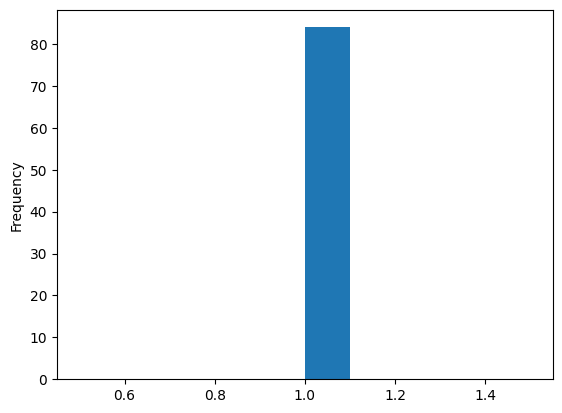

In [228]:
full_2_df.X_input_19.plot.hist()

In [236]:
full_2_df.X_time_trgt_24.describe()

count    84.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: X_time_trgt_24, dtype: float64